In [ ]:
Folsind datele aferente anului 2017 (fisierul v1_world-happiness-report-2017.csv), să se realizeze o predicție a gradului de fericire în funcție:

doar de caracteristica "Family" (tema)
de Produsul intern brut si de gradul de libertate (temă).

In [1]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np  
from sklearn import linear_model

In [2]:
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs, outputs

crtDir =  os.getcwd()
filePath = 'v1_world-happiness-report-2017.csv'

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score')
print('in:  ', inputs[:5])
print('out: ', outputs[:5])

in:   [1.510041952, 1.510041952, 1.510041952, 1.510041952, 1.510041952]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


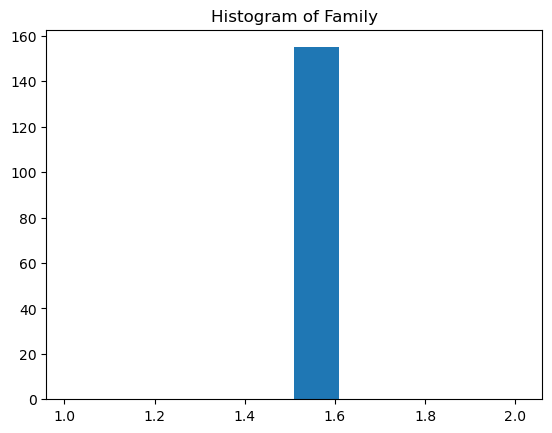

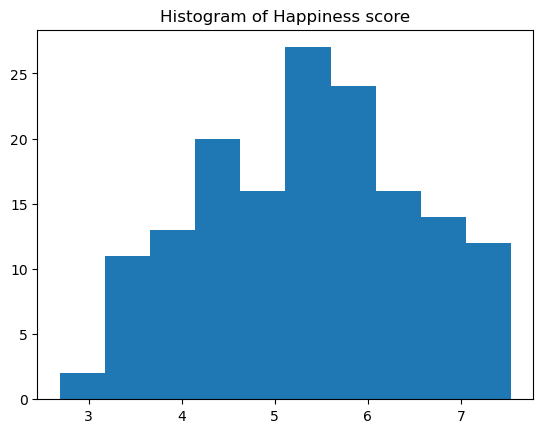

In [3]:

def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, 'Family')
plotDataHistogram(outputs, 'Happiness score')

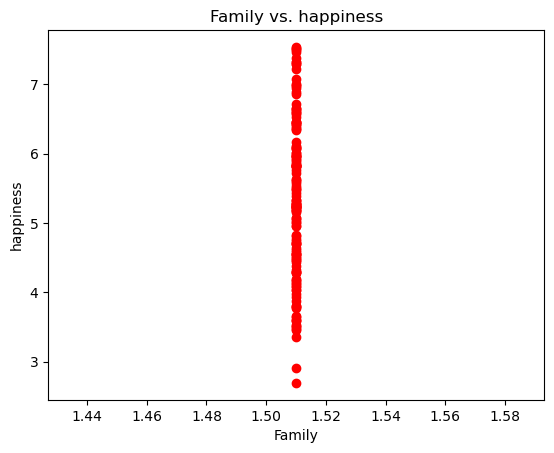

In [4]:
plt.plot(inputs, outputs, 'ro') 
plt.xlabel('Family')
plt.ylabel('happiness')
plt.title('Family vs. happiness')
plt.show()

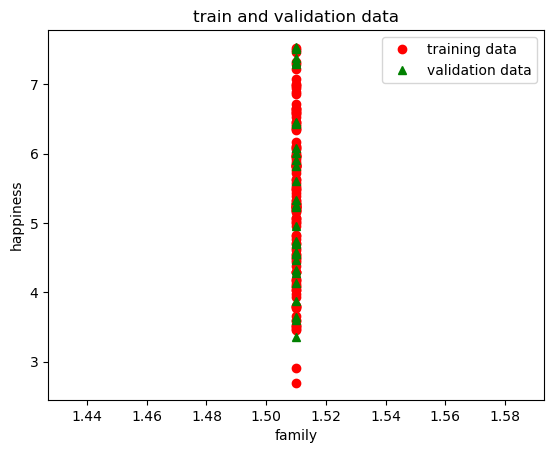

In [5]:

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data are plotted by red and circle sign
plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')     #test data are plotted by green and a triangle sign
plt.title('train and validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [6]:
# learning step: init and train a linear regression model y = f(x) = w0 + w1 * x
# Prediction step: used the trained model to estimate the output for a new input

# using sklearn 
# training data preparation (the sklearn linear model requires as input training data as noSamples x noFeatures array; in the current case, the input must be a matrix of len(trainInputs) lineas and one columns (a single feature is used in this problem))
xx = [[el] for el in trainInputs]

# model initialisation
regressor = linear_model.LinearRegression()
# training the model by using the training inputs and known training outputs
regressor.fit(xx, trainOutputs)
# save the model parameters
w0, w1 = regressor.intercept_, regressor.coef_[0]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

# # using developed code
# from myRegression import MyLinearUnivariateRegression

# # model initialisation
# regressor = MyLinearUnivariateRegression()
# # training the model by using the training inputs and known training outputs
# regressor.fit(trainInputs, trainOutputs)
# # save the model parameters
# w0, w1 = regressor.intercept_, regressor.coef_
# print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

the learnt model: f(x) =  0.4719180650554877  +  3.2328954364819484  * x


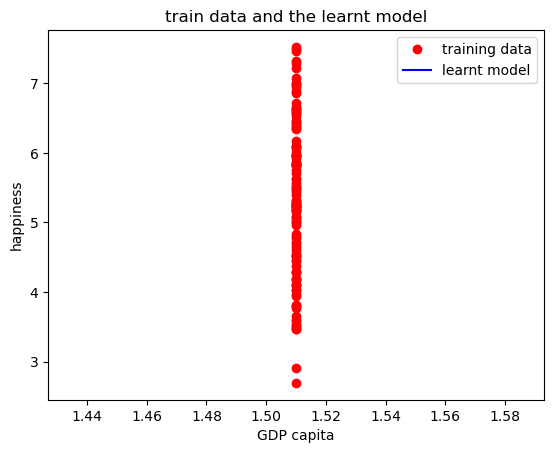

In [7]:
# plot the learnt model
# prepare some synthetic data (inputs are random, while the outputs are computed by the learnt model)
noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')  #train data are plotted by red and circle sign
plt.plot(xref, yref, 'b-', label = 'learnt model')                  #model is plotted by a blue line
plt.title('train data and the learnt model')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

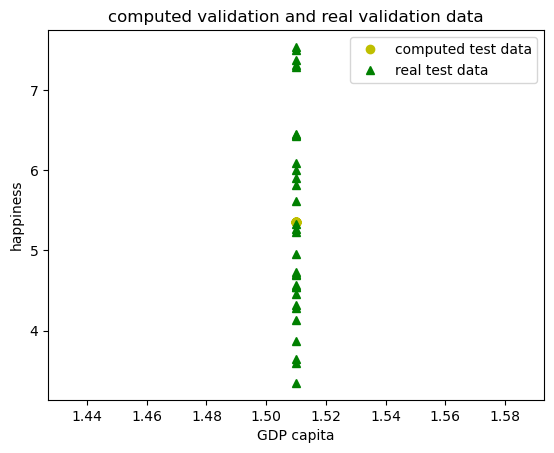

In [8]:
# use the trained model to predict new inputs

# makes predictions for test data (manual)
# computedTestOutputs = [w0 + w1 * el for el in testInputs]

# makes predictions for test data (by tool)
computedValidationOutputs = regressor.predict([[x] for x in validationInputs])

# plot the computed outputs (see how far they are from the real outputs)
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')  #computed test data are plotted yellow red and circle sign
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')  #real test data are plotted by green triangles
plt.title('computed validation and real validation data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [9]:
# compute the differences between the predictions and real outputs
# "manual" computation
error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)

# by using sklearn 
from sklearn.metrics import mean_squared_error

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('prediction error (tool):  ', error)

prediction error (manual):  1.488969965516146
prediction error (tool):   1.488969965516146


In [ ]:
de Produsul intern brut si de gradul de libertate (temă).

in1:   [1.616463184, 1.482383013, 1.48063302, 1.564979553, 1.443571925]
in2:  [0.635422587, 0.626006722, 0.627162635, 0.620070577, 0.617950857]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


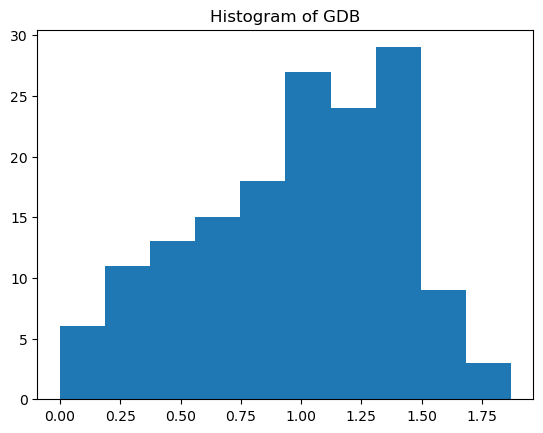

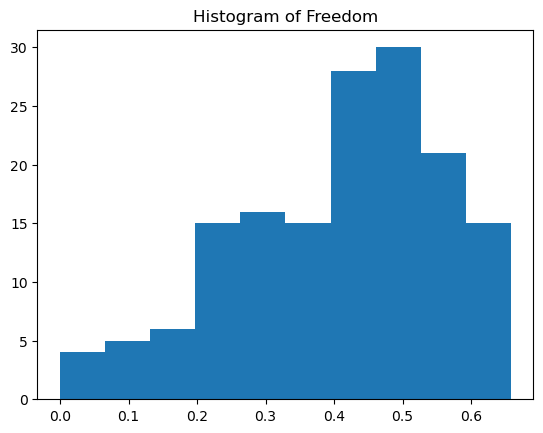

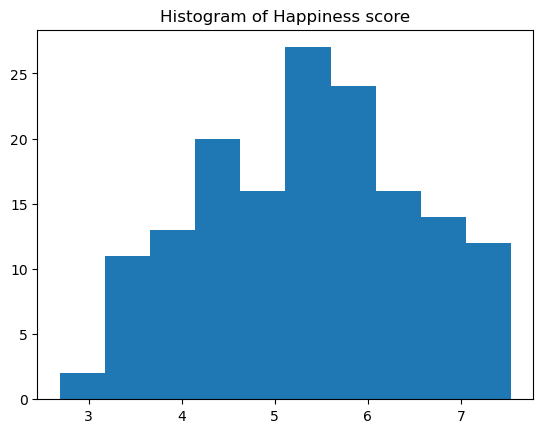

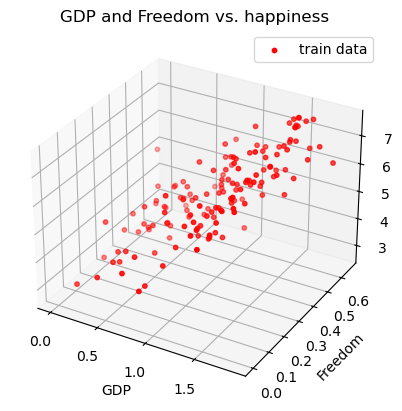

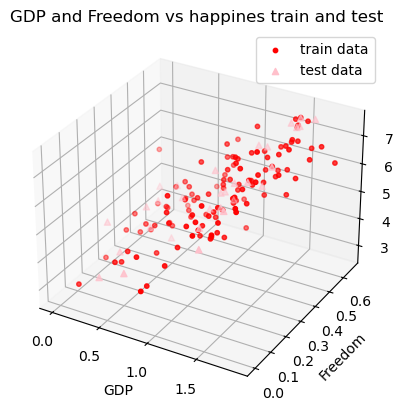

The learnt model: f(x1, x2) =  2.5283663169529045  +  1.8763387360090584  * x1 +  2.314748747723221  * x2


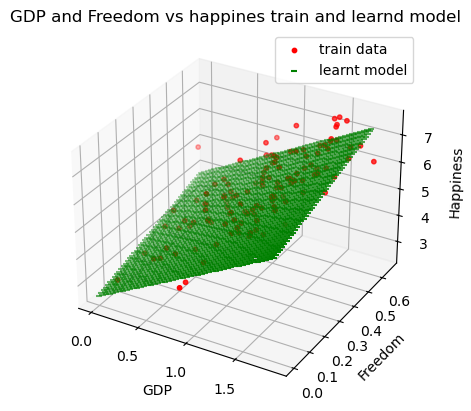

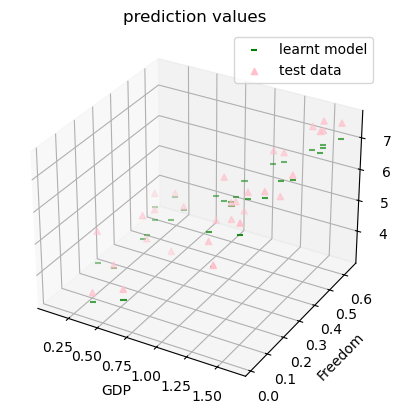

prediction error (manual):  0.2778267436200108
prediction error (tool):   0.2778267436200108


In [29]:
def loadData(fileName, inputVariabName1,inputVariabName2, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabName1)
    inputs1 = [float(data[i][selectedVariable1]) for i in range(len(data))]
    selectedVariable2 = dataNames.index(inputVariabName2)
    inputs2 = [float(data[i][selectedVariable2]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs1,inputs2, outputs

crtDir =  os.getcwd()
filePath = 'v1_world-happiness-report-2017.csv'

inputs1,inputs2, outputs = loadData(filePath, 'Economy..GDP.per.Capita.','Freedom', 'Happiness.Score')
print('in1:  ', inputs1[:5])
print('in2: ',inputs2[:5])
print('out: ', outputs[:5])


#Plot the histograms
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs1, 'GDB')
plotDataHistogram(inputs2,'Freedom')
plotDataHistogram(outputs, 'Happiness score')

def plot3Ddata(x1_train, x2_train, y_train, x1_model=None, x2_model=None, y_model=None, x1_test=None, x2_test=None,
               y_test=None,
               title=None):
    ax = plt.axes(projection='3d')
    if x1_train is not None and len(x1_train)>0:
        ax.scatter(x1_train, x2_train, y_train, c='r', marker='o', label='train data', s=10)
    if x1_model is not None and len(x1_model)>0:
        ax.scatter(x1_model, x2_model, y_model, c='g', marker='_', label='learnt model')
    if x1_test is not None and len(x1_test)>0:
        ax.scatter(x1_test, x2_test, y_test, c='pink', marker='^', label='test data')
    plt.title(title)
    ax.set_xlabel("GDP")
    ax.set_ylabel("Freedom")
    ax.set_zlabel("Happiness")
    plt.legend()
    plt.show()


#Check linearity
plot3Ddata(inputs1,inputs2,outputs,[],[],[],[],[],[],"GDP and Freedom vs. happiness")


#combining inputs into a matrix
X=np.column_stack((inputs1,inputs2))



# split data into training data (80%) and testing data (20%)
np.random.seed(5)
indexes = [i for i in range(len(inputs1))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = X[trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = X[validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plot3Ddata(trainInputs[:,0],trainInputs[:,1],trainOutputs,[],[],[],validationInputs[:,0],validationInputs[:,1],validationOutputs,"GDP and Freedom vs happines train and test")

#Model training
regressor=linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)

# save the model parameters
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
print('The learnt model: f(x1, x2) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2')

# prepare some data
noOfPoints=50
x1ref = []
val = min(inputs1)
step = (max(inputs1) - min(inputs1)) / noOfPoints
for i in range(1, noOfPoints):
    x1ref.append(val)
    val += step
x2ref = []
val = min(inputs2)
step = (max(inputs2) - min(inputs2)) / noOfPoints
for i in range(1, noOfPoints):
    x2ref.append(val)
    val += step

X1,X2=np.meshgrid(x1ref,x2ref)
Y=w0+w1*X1+w2*X2

plot3Ddata(trainInputs[:,0],trainInputs[:,1],trainOutputs,X1,X2,Y,[],[],[],"GDP and Freedom vs happines train and learnd model")


computedValidationOutputs=regressor.predict(validationInputs)
plot3Ddata([],[],[],validationInputs[:,0],validationInputs[:,1],computedValidationOutputs,validationInputs[:,0],validationInputs[:,1],validationOutputs,"prediction values")


error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)

# by using sklearn 
from sklearn.metrics import mean_squared_error

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('prediction error (tool):  ', error)